In [ ]:
#Installing Libraries
!pip install open_clip_torch
!pip install ftfy regex tqdm

In [2]:
# Importing Libraries
import torch
import open_clip
import torchvision
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets
from torchvision import transforms
from torch.utils.data import DataLoader
from tqdm import tqdm

In [3]:
# Setting Device
device = "cuda" if torch.cuda.is_available() else "cpu"


In [4]:
# Loading CLIP Model
model, _, preprocess = open_clip.create_model_and_transforms(
    'ViT-B-16',
    pretrained='openai'
)

tokenizer = open_clip.get_tokenizer('ViT-B-16')
model = model.to(device)
model.eval()
print("CLIP Loaded Successfully!")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


open_clip_model.safetensors:   0%|          | 0.00/599M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


CLIP Loaded Successfully!


In [5]:
# Transforming and Loading CIFAR-100 Dataset
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.48145466, 0.4578275, 0.40821073],
        std=[0.26862954, 0.26130258, 0.27577711]
    )
])
test_dataset = datasets.CIFAR100(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

class_names = test_dataset.classes
test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

print("Test Dataset Loaded!")
print("Number of Classes:", len(class_names))

100%|██████████| 169M/169M [00:05<00:00, 32.6MB/s]


Test Dataset Loaded!
Number of Classes: 100


In [7]:
# Standard Prompt
standard_prompts = [
    f"a photo of a {class_name}"
    for class_name in class_names
]

In [6]:
# Adaptive Prompt Generator
custom_descriptions = {

    "apple": [
        "a red round fruit apple",
        "a fresh apple fruit",
        "a healthy edible apple"
    ],

    "bear": [
        "a large wild bear animal",
        "a furry forest bear",
        "a dangerous brown bear"
    ],

    "bicycle": [
        "a two-wheeled bicycle",
        "a person riding a bicycle",
        "a road bicycle vehicle"
    ],

    "dog": [
        "a furry domestic dog",
        "a canine pet animal",
        "a four-legged dog"
    ],

    "car": [
        "a road vehicle car",
        "a modern automobile",
        "a four-wheel vehicle"
    ]
}


def generate_adaptive_prompts(class_name):

    class_name = class_name.replace("_", " ")

    prompts = [

        f"a photo of a {class_name}",
        f"a realistic image of a {class_name}",
        f"a detailed photo of a {class_name}"
    ]

    if class_name in custom_descriptions:

        prompts.extend(
            custom_descriptions[class_name]
        )

    return prompts

In [10]:
# Encoding Standard Prompt
standard_tokens = tokenizer(
    standard_prompts
).to(device)

with torch.no_grad():

    standard_text_features = model.encode_text(
        standard_tokens
    )

    standard_text_features /= (
        standard_text_features.norm(
            dim=-1,
            keepdim=True
        )
    )

In [11]:
# Encoding Adaptive Prompt
adaptive_text_features = []

with torch.no_grad():

    for class_name in tqdm(class_names):

        prompts = generate_adaptive_prompts(
            class_name
        )

        tokens = tokenizer(prompts).to(device)
        text_features = model.encode_text(tokens)
        text_features /= text_features.norm(
            dim=-1,
            keepdim=True
        )

        averaged_feature = text_features.mean(dim=0)
        averaged_feature /= averaged_feature.norm()
        adaptive_text_features.append(
            averaged_feature
        )

adaptive_text_features = torch.stack(
    adaptive_text_features
)

100%|██████████| 100/100 [00:01<00:00, 89.80it/s]


In [12]:
# Evaluate Standard Prompt
standard_correct = 0
total = 0

with torch.no_grad():

    for images, labels in tqdm(test_loader):
        images = images.to(device)
        image_features = model.encode_image(images)
        image_features /= image_features.norm(
            dim=-1,
            keepdim=True
        )

        similarity = (
            100.0 *
            image_features @ standard_text_features.T
        )

        predictions = similarity.argmax(dim=-1)
        standard_correct += (
            predictions.cpu() == labels
        ).sum().item()

        total += labels.size(0)

standard_accuracy = (
    standard_correct / total
)

print(
    f"Standard Prompt Accuracy: "
    f"{standard_accuracy * 100:.2f}%"
)

100%|██████████| 157/157 [02:03<00:00,  1.27it/s]

Standard Prompt Accuracy: 59.33%


In [13]:
# Evaluating Adaptive Prompts
adaptive_correct = 0
total = 0

all_predictions = []
all_labels = []

with torch.no_grad():

    for images, labels in tqdm(test_loader):
        images = images.to(device)
        image_features = model.encode_image(images)
        image_features /= image_features.norm(
            dim=-1,
            keepdim=True
        )

        similarity = (
            100.0 *
            image_features @ adaptive_text_features.T
        )

        predictions = similarity.argmax(dim=-1)
        adaptive_correct += (
            predictions.cpu() == labels
        ).sum().item()

        total += labels.size(0)

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_labels.extend(
            labels.numpy()
        )

adaptive_accuracy = (
    adaptive_correct / total
)

print(
    f"Adaptive Prompt Accuracy: "
    f"{adaptive_accuracy * 100:.2f}%"
)

100%|██████████| 157/157 [02:05<00:00,  1.25it/s]

Adaptive Prompt Accuracy: 61.09%


In [14]:
# Comparing Results
print("=" * 50)

print("FINAL COMPARISON")

print("=" * 50)

print(
    f"Standard Prompt Accuracy: "
    f"{standard_accuracy * 100:.2f}%"
)

print(
    f"Adaptive Prompt Accuracy: "
    f"{adaptive_accuracy * 100:.2f}%"
)

improvement = (
    adaptive_accuracy - standard_accuracy
) * 100

print(
    f"Improvement: "
    f"{improvement:.2f}%"
)

FINAL COMPARISON
Standard Prompt Accuracy: 59.33%
Adaptive Prompt Accuracy: 61.09%
Improvement: 1.76%


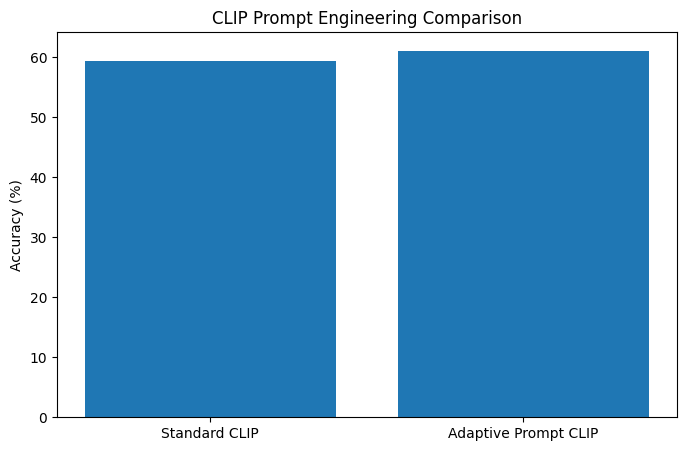

In [15]:
# Visualizing Comparison
methods = [
    "Standard CLIP",
    "Adaptive Prompt CLIP"
]

accuracies = [
    standard_accuracy * 100,
    adaptive_accuracy * 100
]

plt.figure(figsize=(8,5))
plt.bar(methods, accuracies)
plt.ylabel("Accuracy (%)")
plt.title(
    "CLIP Prompt Engineering Comparison"
)

plt.show()

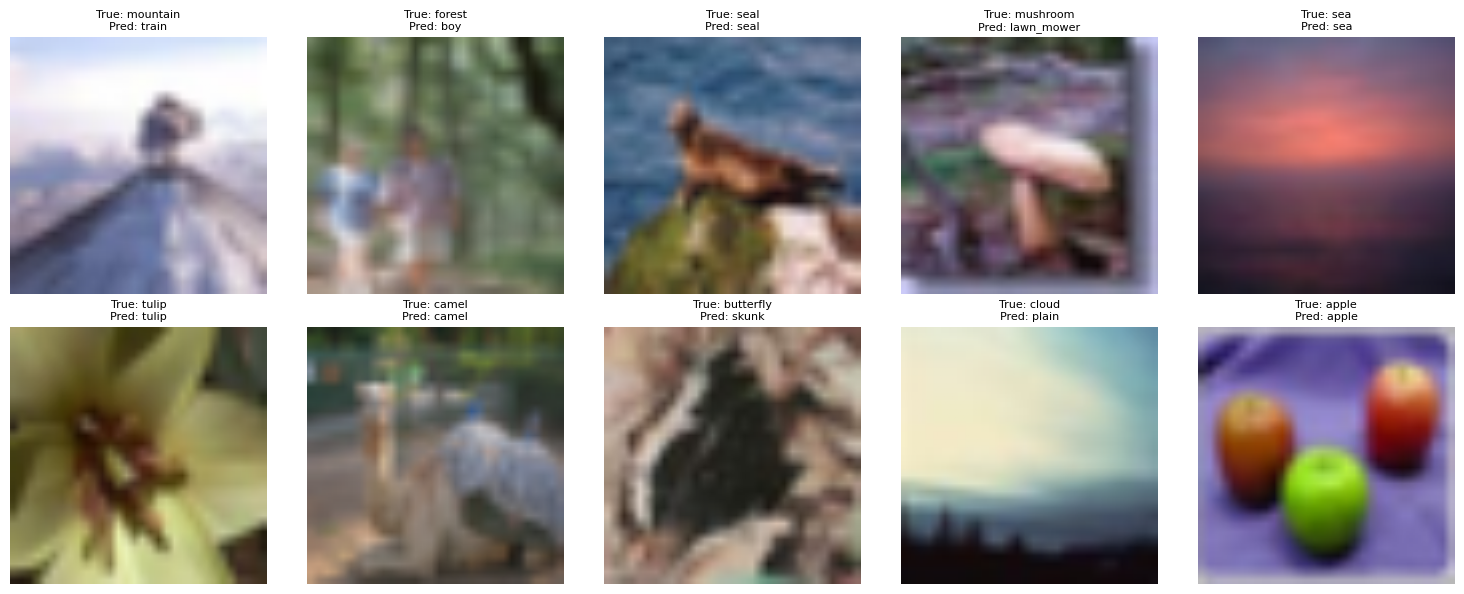

In [16]:
# Visualizing Predictions
def unnormalize(img):

    mean = torch.tensor(
        [0.48145466, 0.4578275, 0.40821073]
    ).view(3,1,1)

    std = torch.tensor(
        [0.26862954, 0.26130258, 0.27577711]
    ).view(3,1,1)

    img = img * std + mean
    return img


images, labels = next(iter(test_loader))
images_gpu = images.to(device)

with torch.no_grad():

    image_features = model.encode_image(
        images_gpu
    )

    image_features /= image_features.norm(
        dim=-1,
        keepdim=True
    )

    similarity = (
        100.0 *
        image_features @ adaptive_text_features.T
    )

    predictions = similarity.argmax(dim=-1)

fig, axes = plt.subplots(
    2,
    5,
    figsize=(15,6)
)

for i, ax in enumerate(axes.flat):

    image = unnormalize(
        images[i]
    ).permute(1,2,0).numpy()

    true_label = class_names[
        labels[i]
    ]

    predicted_label = class_names[
        predictions[i]
    ]

    ax.imshow(image)

    ax.set_title(
        f"True: {true_label}\nPred: {predicted_label}",
        fontsize=8
    )

    ax.axis('off')

plt.tight_layout()
plt.show()